<a href="https://colab.research.google.com/github/gregblast-bot/AutoMagic_Detection/blob/main/MagicCardDetection_Student_Teacher.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MAGIC CARD ORGANIZER TRAINING**
We are going to try to train the data on google collab because why not learn a new skill today.

Below is the definition of functions

# Functions

In [ ]:
# ------------------------------------------------
# --- IMPORTS
# ------------------------------------------------
!pip install requests Pillow numpy opencv-python matplotlib tensorflow
import os
import sys
import requests
import time
import math
import random
import json
from pathlib import Path
from io import BytesIO
from PIL import Image, ImageDraw, ImageFont, ImageFilter  # NEW — added ImageDraw, ImageFilter for synthetic generation
import numpy as np
import cv2
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed
from IPython.display import display, Javascript, HTML
import matplotlib.pyplot as plt
from google.colab.output import eval_js
import base64
import shutil
import tensorflow as tf
from tensorflow.keras import layers, Model
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

# ------------------------------------------------
# --- CONFIG
# ------------------------------------------------
NUM_CARD_IMAGES   = 50000     # Scryfall bulk download target
NUM_OTHER_IMAGES  = 25000    # Synthetic non-card images
IMAGE_SIZE        = 96        # All images will be resized to this size
BATCH_SIZE        = 32        # Number of images to train on at once
NUM_CHANNELS      = 1
DOWNLOAD_THREADS  = 16
SCRYFALL_DELAY    = 0.05
CLASS_CARD        = 0
CLASS_NOT_CARD    = 1
EPOCHS            = 30


# ------------------------------------------------
# --- CONFIG TEACHER/STUDENT
# ------------------------------------------------
# --- Paths (match your existing setup) ---
DATA_DIR = Path("/content/mtg_dataset")
CARD_DIR = DATA_DIR / "card"
NOT_CARD_DIR = DATA_DIR / "not_card"
MODEL_DIR = Path("/content/model_output")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# --- Sizes
STUDENT_SIZE = 96           # must match Arduino kNumCols/kNumRows
TEACHER_SIZE = 224          # MobileNetV2 size
BATCH_SIZE   = 64

# --- KD hyperparameters
KD_TEMPERATURE = 4.0        # softens teacher probs; 3-5 is typical
KD_ALPHA       = 0.7        # weight on soft-target loss vs hard-label loss
LABEL_SMOOTHING = 0.05

# --- Training
TEACHER_EPOCHS_HEAD = 3     # train classifier head with frozen backbone
TEACHER_EPOCHS_FT   = 3    # fine-tune unfrozen top of backbone
STUDENT_EPOCHS      = 20

SEED = 1337
tf.keras.utils.set_random_seed(SEED)

# ------------------------------------------------
# --- PATHS
# ------------------------------------------------
DATA_DIR = Path("/content/mtg_dataset")
CARD_DIR = DATA_DIR / "card"
NOT_CARD_DIR = DATA_DIR / "not_card"
MODEL_DIR = Path("/content/model_output")

TensorFlow version: 2.19.0
GPU: []


In [ ]:
# ------------------------------------------------
# --- FUNCTIONS
# ------------------------------------------------

# Supports bulk urls
def fetch_scryfall_bulk_urls(num_cards=NUM_CARD_IMAGES):
    """
    Use Scryfall's bulk-data endpoint to get image URLs for up to num_cards.
    This avoids hammering the /cards/random endpoint one-by-one.

    Returns a list of (index, image_url) tuples.
    """
    print("Fetching Scryfall bulk data catalog...")
    bulk_resp = requests.get(
        "https://api.scryfall.com/bulk-data",
        headers={"User-Agent": "MTGCardDetector/1.0"},
        timeout=30,
    )
    bulk_resp.raise_for_status()
    bulk_list = bulk_resp.json()["data"]

    # Find the "default_cards" bulk file (smallest complete set)
    default_bulk = None
    for entry in bulk_list:
        if entry["type"] == "default_cards":
            default_bulk = entry
            break

    if not default_bulk:
        # Fallback to oracle_cards if default not found
        for entry in bulk_list:
            if entry["type"] == "oracle_cards":
                default_bulk = entry
                break

    if not default_bulk:
        raise RuntimeError("Could not find a suitable bulk data source on Scryfall")

    download_uri = default_bulk["download_uri"]
    print(f"Downloading bulk JSON from: {download_uri}")
    print(f"  (This is a large file — may take 1-3 minutes)")

    bulk_data_resp = requests.get(
        download_uri,
        headers={"User-Agent": "MTGCardDetector/1.0"},
        timeout=300,
        stream=True,
    )
    bulk_data_resp.raise_for_status()

    # Parse the JSON — this is the big operation
    print("Parsing bulk JSON...")
    all_cards = json.loads(bulk_data_resp.content)
    print(f"  Total cards in Scryfall database: {len(all_cards)}")

    # Extract image URLs, preferring "small" size for speed/storage
    url_list = []
    for card in all_cards:
        img_url = None

        # Standard cards
        image_uris = card.get("image_uris")
        if image_uris:
            img_url = (image_uris.get("normal") or
                      image_uris.get("large") or
                      image_uris.get("small"))

        # Double-faced / multi-face cards — take front face
        if not img_url:
          faces = card.get("card_faces", [])
          if faces and "image_uris" in faces[0]:
            img_url = (faces[0]["image_uris"].get("normal") or
                      faces[0]["image_uris"].get("large") or
                      faces[0]["image_uris"].get("small"))

        if img_url:
            url_list.append(img_url)

    print(f"  Found {len(url_list)} cards with image URLs")

    # Shuffle and trim to requested count
    random.shuffle(url_list)
    url_list = url_list[:num_cards]

    return list(enumerate(url_list))


def _download_single_card(args):
    """Worker function for threaded card download."""
    idx, url = args
    try:
        resp = requests.get(url, timeout=15)
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        img.save(CARD_DIR / f"card_{idx:06d}.jpg")
        return True
    except Exception:
        return False


def fetch_scryfall_cards(num_cards=NUM_CARD_IMAGES):
    """
    Download MTG card images using bulk data + parallel downloads.
    Much faster than one-by-one random API calls.
    """
    # Step 1: Get all URLs from bulk data
    indexed_urls = fetch_scryfall_bulk_urls(num_cards)
    total = len(indexed_urls)
    print(f"\nDownloading {total} card images with {DOWNLOAD_THREADS} threads...")

    # Step 2: Parallel download
    downloaded = 0
    errors = 0
    start_time = time.time()

    with ThreadPoolExecutor(max_workers=DOWNLOAD_THREADS) as executor:
        futures = {executor.submit(_download_single_card, item): item for item in indexed_urls}

        for future in as_completed(futures):
            if future.result():
                downloaded += 1
            else:
                errors += 1

            done = downloaded + errors
            if done % 1000 == 0:
                elapsed = time.time() - start_time
                rate = done / elapsed if elapsed > 0 else 0
                eta = (total - done) / rate if rate > 0 else 0
                print(f"  Progress: {done}/{total} ({downloaded} ok, {errors} err) "
                      f"— {rate:.0f} img/s, ETA {eta/60:.1f} min")

    elapsed = time.time() - start_time
    print(f"\nDone! Downloaded {downloaded} card images in {elapsed/60:.1f} min "
          f"({errors} errors)")
    return downloaded

# def fetch_non_card_images(num_images=NUM_OTHER_IMAGES):
#   """
#   Download random non-card images for negative samples.
#   """

#   print(f"Fetching {num_images} non-card images...")
#   downloaded = 0
#   errors = 0
#   max_errors = 50

#   while downloaded < num_images and errors < max_errors:
#       try:
#           # Picsum returns a random image at the requested size
#           resp = requests.get(
#               f"https://picsum.photos/146/204",  # Similar aspect ratio to MTG cards
#               timeout=10,
#           )
#           resp.raise_for_status()

#           img = Image.open(BytesIO(resp.content)).convert("RGB")
#           img.save(NOT_CARD_DIR / f"other_{downloaded:04d}.jpg")
#           downloaded += 1
#           errors = 0

#           if downloaded % 50 == 0:
#               print(f"  Downloaded {downloaded}/{num_images} non-card images")

#           time.sleep(0.3)

#       except Exception as e:
#           errors += 1
#           if errors % 10 == 0:
#               print(f"  Warning: {errors} errors so far. Last: {e}")
#           time.sleep(0.5)

#   print(f"Downloaded {downloaded} non-card images ({errors} final error count)")
#   return downloaded

# If datasets isn't installed: !pip install -q datasets
from datasets import load_dataset

def fetch_non_card_images(num_images=NUM_OTHER_IMAGES):
    print(f"Streaming {num_images} non-card images from COCO...")
    ds = load_dataset(
        "detection-datasets/coco",
        split="train",
        streaming=True,
    )
    # Shuffle with a buffer so we don't get a contiguous slice of the dataset
    ds = ds.shuffle(seed=42, buffer_size=500)

    saved, skipped = 0, 0
    start = time.time()

    for example in ds:
        if saved >= num_images:
            break
        try:
            img = example["image"].convert("RGB")
            # Downscale large images before saving since we resize to 96 anyway
            img.thumbnail((256, 256))
            img.save(NOT_CARD_DIR / f"other_{saved:06d}.jpg", quality=85)
            saved += 1
            if saved % 500 == 0:
                rate = saved / (time.time() - start)
                eta = (num_images - saved) / rate if rate > 0 else 0
                print(f"  {saved}/{num_images} — {rate:.0f} img/s, ETA {eta:.0f}s")
        except Exception as e:
            skipped += 1
            if skipped % 50 == 0:
                print(f"  warning: {skipped} skipped so far")

    elapsed = time.time() - start
    print(f"Done! {saved} images in {elapsed/60:.1f} min ({skipped} skipped)")
    return saved

In [ ]:

# ------------------------------------------------
# --- AUGMENTATION PARAMETERS
# ------------------------------------------------
PERSPECTIVE_INTENSITY = 0.3
BRIGHTNESS_MAX_DELTA = 0.3
BLUR_MAX_KERNEL = 7
NOISE_FACTOR = 0.05


# ------------------------------------------------
# --- AUGMENTATION FUNCTIONS
# ------------------------------------------------
def perspective_warp_cv(image_np):
    h, w = image_np.shape[:2]
    max_shift = int(min(h, w) * PERSPECTIVE_INTENSITY)
    if max_shift < 2:
        return image_np

    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])

    def _shift():
        return random.randint(max_shift // 2, max_shift)

    style = random.choice(["top_narrow", "bottom_narrow", "left_narrow", "right_narrow"])

    if style == "top_narrow":
        dst = np.float32([[_shift(), _shift()], [w - _shift(), _shift()], [w, h], [0, h]])
    elif style == "bottom_narrow":
        dst = np.float32([[0, 0], [w, 0], [w - _shift(), h - _shift()], [_shift(), h - _shift()]])
    elif style == "left_narrow":
        dst = np.float32([[_shift(), _shift()], [w, 0], [w, h], [_shift(), h - _shift()]])
    else:
        dst = np.float32([[0, 0], [w - _shift(), _shift()], [w - _shift(), h - _shift()], [0, h]])

    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(image_np, M, (w, h),
                                borderMode=cv2.BORDER_CONSTANT,
                                borderValue=(0, 0, 0))

def adjust_brightness(image_np):
    img_tensor = tf.image.random_brightness(image_np, max_delta=BRIGHTNESS_MAX_DELTA)
    img_tensor = tf.clip_by_value(img_tensor, 0, 255)

    return img_tensor.numpy().astype(np.uint8)

def gaussian_blur(image_np):
    k = random.choice([3, 5, 7])
    k = min(k, BLUR_MAX_KERNEL)

    return cv2.GaussianBlur(image_np, (k, k), 0)

def add_noise(image_np):
    img_float = image_np.astype(np.float32) / 255.0
    noise = tf.random.normal(shape=img_float.shape, mean=0.0, stddev=NOISE_FACTOR)
    noisy = tf.clip_by_value(img_float + noise, 0.0, 1.0)

    return (noisy.numpy() * 255).astype(np.uint8)

def motion_blur(image_np):
    """Simulate hand motion during capture."""
    k_size = random.choice([5, 7, 9])
    direction = random.choice(["horizontal", "vertical", "diagonal"])
    kernel = np.zeros((k_size, k_size), dtype=np.float32)
    if direction == "horizontal":
        kernel[k_size // 2, :] = 1.0
    elif direction == "vertical":
        kernel[:, k_size // 2] = 1.0
    else:
        np.fill_diagonal(kernel, 1.0)
    kernel /= kernel.sum()
    return cv2.filter2D(image_np, -1, kernel)


def partial_crop(image_np):
    """Simulate a card partially in/out of frame."""
    h, w = image_np.shape[:2]
    crop_frac = random.uniform(0.2, 0.5)
    side = random.choice(["top", "bottom", "left", "right"])
    bg_val = random.randint(20, 80)
    result = np.full_like(image_np, bg_val)
    if side == "top":
        cut = int(h * crop_frac)
        result[cut:, :] = image_np[:h - cut, :]
    elif side == "bottom":
        cut = int(h * crop_frac)
        result[:h - cut, :] = image_np[cut:, :]
    elif side == "left":
        cut = int(w * crop_frac)
        result[:, cut:] = image_np[:, :w - cut]
    else:
        cut = int(w * crop_frac)
        result[:, :w - cut] = image_np[:, cut:]
    return result

# ------------------------------------------------
# --- Create the dataset here
# ------------------------------------------------

# Set the operations for the card creation set
operations = [
    perspective_warp_cv,
    adjust_brightness,
    gaussian_blur,
    add_noise,
    motion_blur,
    partial_crop,
]

def generate_augmented_dataset_simple(augments_per_image=2):
    """
    For each image in CARD_DIR, apply a random subset of operations
    and save the augmented results into CARD_DIR alongside originals.
    """
    image_paths = list(CARD_DIR.glob("*.jpg"))
    print(f"Augmenting {len(image_paths)} images, {augments_per_image}x each...")

    count = 0
    for img_path in image_paths:
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        for i in range(augments_per_image):
            augmented = img.copy()

            num_ops = random.randint(1, len(operations))
            chosen_ops = random.sample(operations, num_ops)

            for op in chosen_ops:
                augmented = op(augmented)

            out_name = f"{img_path.stem}_aug{i:02d}.jpg"
            cv2.imwrite(str(CARD_DIR / out_name), augmented)
            count += 1

        # --- NEW: progress logging so you're not staring at silence ---
        if (count // augments_per_image) % 5000 == 0 and count > 0:
            print(f"  Augmented {count // augments_per_image}/{len(image_paths)} originals...")

    print(f"Saved {count} augmented images to {CARD_DIR}")
    return count

def generate_augmented_dataset(bg_paths, augments_per_image=2):
    """
    Two kinds of augments:
    - Half are composited onto real backgrounds (simulates camera view)
    - Half are light warps of the full-frame card (helps learn card textures)
    """
    image_paths = list(CARD_DIR.glob("*.jpg"))
    print(f"Augmenting {len(image_paths)} cards ({augments_per_image}x each)...")
    print(f"  Using {len(bg_paths)} background images for compositing")

    count = 0
    for img_path in image_paths:
        card = Image.open(img_path).convert("L")

        for i in range(augments_per_image):
            if i % 2 == 0 and bg_paths:
                # --- COMPOSITE: card on a real background ---
                bg = Image.open(random.choice(bg_paths)).convert("L")
                bg = bg.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)

                # Card fills 50-85% of the frame height
                # (at 96px, 50% = 48px which is still recognizable)
                scale = random.uniform(0.75, 0.95)
                card_h = int(IMAGE_SIZE * scale)
                card_w = int(card_h * 0.72)  # MTG aspect ratio
                card_resized = card.resize((card_w, card_h), Image.LANCZOS)

                # Random position (keep card fully in frame)
                max_x = max(IMAGE_SIZE - card_w, 0)
                max_y = max(IMAGE_SIZE - card_h, 0)
                x = random.randint(0, max_x)
                y = random.randint(0, max_y)

                result = bg.copy()
                result.paste(card_resized, (x, y))
                result_np = np.array(result)
            else:
                # --- LIGHT WARP: keep card full-frame but add mild distortion ---
                img_np = np.array(card.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS))
                result_np = perspective_warp_cv(img_np)
                if random.random() > 0.5:
                    result_np = adjust_brightness(result_np)

            out_name = f"{img_path.stem}_aug{i:02d}.jpg"
            cv2.imwrite(str(CARD_DIR / out_name), result_np)
            count += 1

        if (count // augments_per_image) % 5000 == 0 and count > 0:
            print(f"  Augmented {count // augments_per_image}/{len(image_paths)} originals...")

    print(f"Saved {count} augmented images to {CARD_DIR}")
    return count

In [ ]:
# ------------------------------------------------
# --- Generate instead of download augmentation
# ------------------------------------------------

def _generate_random_gradient(size):
    """Generate a random linear gradient image."""
    img = np.zeros((size, size, 3), dtype=np.uint8)
    c1 = np.array([random.randint(0, 255) for _ in range(3)])
    c2 = np.array([random.randint(0, 255) for _ in range(3)])

    direction = random.choice(["horizontal", "vertical", "diagonal"])
    for i in range(size):
        t = i / max(size - 1, 1)
        color = (c1 * (1 - t) + c2 * t).astype(np.uint8)
        if direction == "horizontal":
            img[:, i] = color
        elif direction == "vertical":
            img[i, :] = color
        else:
            for j in range(size):
                td = (i + j) / (2 * max(size - 1, 1))
                img[i, j] = (c1 * (1 - td) + c2 * td).astype(np.uint8)
    return img


def _generate_random_shapes(size):
    """Generate an image with random geometric shapes."""
    bg_color = tuple(random.randint(0, 255) for _ in range(3))
    img = Image.new("RGB", (size, size), bg_color)
    draw = ImageDraw.Draw(img)

    num_shapes = random.randint(3, 15)
    for _ in range(num_shapes):
        color = tuple(random.randint(0, 255) for _ in range(3))
        shape_type = random.choice(["rect", "ellipse", "line", "polygon"])
        x1, y1 = random.randint(0, size - 1), random.randint(0, size - 1)
        x2, y2 = random.randint(0, size - 1), random.randint(0, size - 1)

        # Ensure x1 <= x2 and y1 <= y2 (required by rect/ellipse)
        if x1 > x2: x1, x2 = x2, x1
        if y1 > y2: y1, y2 = y2, y1
        if x1 == x2: x2 = min(x2 + 1, size - 1)
        if y1 == y2: y2 = min(y2 + 1, size - 1)

        if shape_type == "rect":
            draw.rectangle([x1, y1, x2, y2], fill=color)
        elif shape_type == "ellipse":
            draw.ellipse([x1, y1, x2, y2], fill=color)
        elif shape_type == "line":
            width = random.randint(1, 8)
            draw.line([x1, y1, x2, y2], fill=color, width=width)
        else:
            num_points = random.randint(3, 6)
            points = [(random.randint(0, size), random.randint(0, size))
                      for _ in range(num_points)]
            draw.polygon(points, fill=color)

    return np.array(img)


def _generate_noise_image(size):
    """Generate pure random noise."""
    noise_type = random.choice(["uniform", "gaussian", "salt_pepper"])
    if noise_type == "uniform":
        return np.random.randint(0, 256, (size, size, 3), dtype=np.uint8)
    elif noise_type == "gaussian":
        mean = random.randint(64, 192)
        std = random.randint(20, 80)
        img = np.random.normal(mean, std, (size, size, 3))
        return np.clip(img, 0, 255).astype(np.uint8)
    else:
        img = np.zeros((size, size, 3), dtype=np.uint8)
        img[:] = [random.randint(0, 255) for _ in range(3)]
        num_pixels = size * size // 4
        for _ in range(num_pixels):
            x, y = random.randint(0, size - 1), random.randint(0, size - 1)
            img[y, x] = [255, 255, 255] if random.random() > 0.5 else [0, 0, 0]
        return img


def _generate_texture_image(size):
    """Generate a procedural texture (stripes, checkerboard, grid, etc.)."""
    pattern = random.choice(["stripes", "checkerboard", "grid", "circles", "waves"])
    img = np.zeros((size, size, 3), dtype=np.uint8)
    c1 = np.array([random.randint(0, 255) for _ in range(3)], dtype=np.uint8)
    c2 = np.array([random.randint(0, 255) for _ in range(3)], dtype=np.uint8)
    freq = random.randint(4, 20)

    if pattern == "stripes":
        for i in range(size):
            stripe = (i // max(size // freq, 1)) % 2
            img[i, :] = c1 if stripe == 0 else c2

    elif pattern == "checkerboard":
        block = max(size // freq, 1)
        for i in range(size):
            for j in range(size):
                check = ((i // block) + (j // block)) % 2
                img[i, j] = c1 if check == 0 else c2

    elif pattern == "grid":
        img[:] = c1
        spacing = max(size // freq, 2)
        thickness = random.randint(1, 3)
        for i in range(0, size, spacing):
            img[max(0, i - thickness):i + thickness, :] = c2
            img[:, max(0, i - thickness):i + thickness] = c2

    elif pattern == "circles":
        pil_img = Image.new("RGB", (size, size), tuple(c1))
        draw = ImageDraw.Draw(pil_img)
        cx, cy = size // 2, size // 2
        for r in range(0, size, max(size // freq, 2)):
            ring = r % 2
            color = tuple(c1) if ring == 0 else tuple(c2)
            draw.ellipse([cx - r, cy - r, cx + r, cy + r], outline=color, width=2)
        img = np.array(pil_img)

    elif pattern == "waves":
        for i in range(size):
            for j in range(size):
                val = math.sin(i / max(size / freq, 1) * math.pi * 2) + \
                      math.sin(j / max(size / freq, 1) * math.pi * 2)
                t = (val + 2) / 4
                img[i, j] = (c1 * (1 - t) + c2 * t).astype(np.uint8)

    return img


def _generate_blurred_photo_sim(size):
    """Generate something that looks like a blurry, out-of-focus photo."""
    base = _generate_random_shapes(size)
    pil_img = Image.fromarray(base)
    blur_radius = random.randint(3, 12)
    pil_img = pil_img.filter(ImageFilter.GaussianBlur(radius=blur_radius))
    return np.array(pil_img)


def _generate_solid_with_text_sim(size):
    """Generate a solid/gradient background with random scribbles."""
    bg = _generate_random_gradient(size)
    pil_img = Image.fromarray(bg)
    draw = ImageDraw.Draw(pil_img)

    num_lines = random.randint(3, 10)
    for _ in range(num_lines):
        y = random.randint(0, size - 1)
        x_start = random.randint(0, size // 3)
        x_end = random.randint(size // 2, size)
        color = tuple(random.randint(0, 255) for _ in range(3))
        draw.line([(x_start, y), (x_end, y)], fill=color, width=random.randint(1, 3))

    return np.array(pil_img)

def generate_camera_realistic_negatives(num_images):
    """Generate negatives that look like what the camera actually sees."""
    print(f"Generating {num_images} camera-realistic negative images...")
    count = 0
    start = time.time()

    generators = [
        _gen_solid_surface, _gen_wood_grain, _gen_fabric_texture,
        _gen_text_document, _gen_partial_occlusion, _gen_blurry_mess,
        _gen_edge_case_rectangle, _gen_dark_frame, _gen_overexposed_frame,
        _gen_gradient_lighting,
    ]

    while count < num_images:
        gen_func = random.choice(generators)
        try:
            img_np = gen_func(IMAGE_SIZE)
            if img_np is not None:
                Image.fromarray(img_np).save(NOT_CARD_DIR / f"neg_{count:06d}.jpg")
                count += 1
                if count % 2000 == 0:
                    print(f"  Generated {count}/{num_images} ({time.time()-start:.0f}s)")
        except Exception:
            continue
    print(f"Generated {count} camera-realistic negatives in {time.time()-start:.0f}s")
    return count


def _gen_solid_surface(size):
    base_colors = [(180,150,120),(100,70,45),(200,200,200),(240,235,230),(40,40,45),(20,60,120),(30,80,40)]
    color = np.array(random.choice(base_colors), dtype=np.float32)
    img = np.full((size, size, 3), color, dtype=np.float32)
    noise = np.random.normal(0, random.uniform(3, 12), img.shape)
    return np.clip(img + noise, 0, 255).astype(np.uint8)

def _gen_wood_grain(size):
    img = np.zeros((size, size, 3), dtype=np.uint8)
    base_r, base_g, base_b = random.randint(120,180), random.randint(80,130), random.randint(40,80)
    freq, phase = random.uniform(0.05, 0.15), random.uniform(0, 2*math.pi)
    for y in range(size):
        wave = math.sin(y * freq + phase) * 15
        for x in range(size):
            grain = math.sin((x + wave) * 0.3) * 10
            img[y,x] = [np.clip(base_r+grain+random.gauss(0,4),0,255),
                         np.clip(base_g+grain*0.7+random.gauss(0,3),0,255),
                         np.clip(base_b+grain*0.4+random.gauss(0,2),0,255)]
    return img

def _gen_fabric_texture(size):
    base = np.array([random.randint(20,200) for _ in range(3)], dtype=np.float32)
    img = np.full((size, size, 3), base, dtype=np.float32)
    spacing = random.randint(2, 5)
    for y in range(size):
        for x in range(size):
            if (x % spacing == 0) or (y % spacing == 0):
                img[y,x] *= random.uniform(0.85, 0.95)
    return np.clip(img + np.random.normal(0, random.uniform(2,8), img.shape), 0, 255).astype(np.uint8)

def _gen_text_document(size):
    bg = random.randint(230, 255)
    img = Image.new("RGB", (size, size), (bg, bg, bg-5))
    draw = ImageDraw.Draw(img)
    tc = random.randint(10, 80)
    y = random.randint(5, 15)
    while y < size - 5:
        lw = random.randint(size//4, size-10)
        draw.rectangle([random.randint(3,15), y, lw, y+random.randint(1,3)], fill=(tc,tc,tc))
        y += random.randint(4, 10)
    return np.array(img)

def _gen_partial_occlusion(size):
    bg = random.choice([(180,150,120),(200,200,200),(40,40,45)])
    img = np.clip(np.full((size,size,3), bg, dtype=np.int16) + np.random.normal(0,5,(size,size,3)).astype(np.int16), 0, 255).astype(np.uint8)
    pil_img = Image.fromarray(img)
    draw = ImageDraw.Draw(pil_img)
    skin = random.choice([(220,185,155),(180,140,105),(140,100,70),(90,60,40)])
    cx, cy = random.randint(size//4, 3*size//4), random.randint(size//4, 3*size//4)
    rx, ry = random.randint(size//4, size//2), random.randint(size//6, size//3)
    draw.ellipse([cx-rx, cy-ry, cx+rx, cy+ry], fill=skin)
    return np.array(pil_img)

def _gen_blurry_mess(size):
    img = Image.new("RGB", (size, size), tuple(random.randint(40,200) for _ in range(3)))
    draw = ImageDraw.Draw(img)
    for _ in range(random.randint(2, 6)):
        c = tuple(random.randint(0,255) for _ in range(3))
        coords = sorted([random.randint(0,size) for _ in range(2)]), sorted([random.randint(0,size) for _ in range(2)])
        draw.rectangle([coords[0][0], coords[1][0], coords[0][1], coords[1][1]], fill=c)
    return np.array(img.filter(ImageFilter.GaussianBlur(radius=random.randint(8,20))))

def _gen_edge_case_rectangle(size):
    bg = np.full((size,size,3), [random.randint(100,220)]*3, dtype=np.uint8)
    pil_img = Image.fromarray(bg)
    draw = ImageDraw.Draw(pil_img)
    w, h = random.randint(size//3, size*2//3), random.randint(size//4, size*3//4)
    x, y = random.randint(0, size-w), random.randint(0, size-h)
    draw.rectangle([x, y, x+w, y+h], fill=tuple(random.randint(0,255) for _ in range(3)), outline=(0,0,0), width=1)
    return np.array(pil_img)

def _gen_dark_frame(size):
    b = random.randint(5, 40)
    return np.clip(np.full((size,size,3), b, dtype=np.float32) + np.random.normal(0, random.uniform(5,20), (size,size,3)), 0, 255).astype(np.uint8)

def _gen_overexposed_frame(size):
    b = random.randint(210, 250)
    return np.clip(np.full((size,size,3), b, dtype=np.float32) + np.random.normal(0, random.uniform(3,10), (size,size,3)), 0, 255).astype(np.uint8)

def _gen_gradient_lighting(size):
    base = np.array([random.randint(80,200) for _ in range(3)], dtype=np.float32)
    img = np.zeros((size,size,3), dtype=np.float32)
    lx, ly = random.choice([(0,0),(size,0),(0,size),(size,size)])
    max_dist = math.sqrt(2) * size
    for y in range(size):
        for x in range(size):
            falloff = 1.0 - (math.sqrt((x-lx)**2 + (y-ly)**2) / max_dist) * 0.5
            img[y,x] = base * falloff
    return np.clip(img + np.random.normal(0, 4, img.shape), 0, 255).astype(np.uint8)

# All synthetic generators with equal weighting
_SYNTH_GENERATORS = [
    _generate_random_gradient,
    _generate_random_shapes,
    _generate_noise_image,
    _generate_texture_image,
    _generate_blurred_photo_sim,
    _generate_solid_with_text_sim,
]


def generate_non_card_images(num_images=NUM_OTHER_IMAGES):
    """
    Generate synthetic non-card images locally
    These provide diverse negative samples: gradients, shapes, noise,
    textures, blurry scenes, and scribble patterns.
    """
    print(f"Generating {num_images} synthetic non-card images...")
    start_time = time.time()
    log_interval = max(num_images // 100, 100)  # ~100 updates, minimum every 100

    for i in range(num_images):
        generator = random.choice(_SYNTH_GENERATORS)
        gen_size = random.choice([96, 128, 146, 160, 200])
        img_np = generator(gen_size)

        img = Image.fromarray(img_np).resize((146, 204), Image.LANCZOS)
        img.save(NOT_CARD_DIR / f"other_{i:06d}.jpg", quality=85)

        if (i + 1) % log_interval == 0 or (i + 1) == num_images:
            elapsed = time.time() - start_time
            rate = (i + 1) / elapsed if elapsed > 0 else 0
            eta = (num_images - i - 1) / rate if rate > 0 else 0
            pct = (i + 1) / num_images
            bar_len = 30
            filled = int(bar_len * pct)
            bar = "█" * filled + "░" * (bar_len - filled)
            print(f"\r  [{bar}] {pct:.0%}  {i + 1}/{num_images} — "
                  f"{rate:.0f} img/s, ETA {eta:.0f}s", end="")

    elapsed = time.time() - start_time
    print(f"\nDone! Generated {num_images} non-card images in {elapsed/60:.1f} min")
    return num_images

# Download / Generator dataset

---



In [ ]:
# Clean out old data
for d in [CARD_DIR, NOT_CARD_DIR]:
    if d.exists():
        shutil.rmtree(d)

CARD_DIR.mkdir(parents=True, exist_ok=True)
NOT_CARD_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# === STEP 1: Download card originals ===
cards_downloaded = fetch_scryfall_cards()
num_originals = len(list(CARD_DIR.glob("*.jpg")))
print(f"Original card images: {num_originals}")

# === STEP 2: Generate negatives FIRST ===
target_negatives = num_originals * 3
picsum_count = fetch_non_card_images(int(target_negatives * 0.80))
synthetic_count = generate_camera_realistic_negatives(int(target_negatives * 0.20))
non_cards_generated = len(list(NOT_CARD_DIR.glob("*.jpg")))

# === STEP 3: online augmentation only — no disk augments ===
# (we used to call generate_augmented_dataset() here, but the new pipeline
#  does augmentation on-the-fly via tf.data, so writing aug files to disk
#  just wastes space and creates label-noise risk.)
total_card_files = len(list(CARD_DIR.glob("*.jpg")))

print(f"\n{'='*50}")
print(f"  DATASET SUMMARY")
print(f"  Card images:     {total_card_files}")
print(f"  Non-card images: {non_cards_generated}")
print(f"  Balance ratio:   {total_card_files / max(non_cards_generated, 1):.2f}:1.00")
print(f"{'='*50}")

Fetching Scryfall bulk data catalog...
  (This is a large file — may take 1-3 minutes)
Parsing bulk JSON...
  Total cards in Scryfall database: 113938
  Found 113776 cards with image URLs

  Progress: 1000/50000 (1000 ok, 0 err) — 102 img/s, ETA 8.0 min
  Progress: 2000/50000 (2000 ok, 0 err) — 113 img/s, ETA 7.1 min
  Progress: 3000/50000 (3000 ok, 0 err) — 117 img/s, ETA 6.7 min
  Progress: 4000/50000 (4000 ok, 0 err) — 117 img/s, ETA 6.6 min
  Progress: 5000/50000 (5000 ok, 0 err) — 118 img/s, ETA 6.3 min
  Progress: 6000/50000 (6000 ok, 0 err) — 120 img/s, ETA 6.1 min
  Progress: 7000/50000 (7000 ok, 0 err) — 119 img/s, ETA 6.0 min
  Progress: 8000/50000 (8000 ok, 0 err) — 119 img/s, ETA 5.9 min
  Progress: 9000/50000 (9000 ok, 0 err) — 120 img/s, ETA 5.7 min
  Progress: 10000/50000 (10000 ok, 0 err) — 121 img/s, ETA 5.5 min
  Progress: 11000/50000 (11000 ok, 0 err) — 121 img/s, ETA 5.4 min
  Progress: 12000/50000 (12000 ok, 0 err) — 122 img/s, ETA 5.2 min
  Progress: 13000/50000 (

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

  500/120000 — 52 img/s, ETA 2291s
  1000/120000 — 65 img/s, ETA 1844s
  1500/120000 — 70 img/s, ETA 1682s
  2000/120000 — 74 img/s, ETA 1591s
  2500/120000 — 68 img/s, ETA 1726s
  3000/120000 — 71 img/s, ETA 1655s
  3500/120000 — 73 img/s, ETA 1604s
  4000/120000 — 74 img/s, ETA 1560s
  4500/120000 — 76 img/s, ETA 1527s
  5000/120000 — 77 img/s, ETA 1498s
  5500/120000 — 74 img/s, ETA 1544s
  6000/120000 — 75 img/s, ETA 1514s
  6500/120000 — 76 img/s, ETA 1491s
  7000/120000 — 77 img/s, ETA 1469s
  7500/120000 — 78 img/s, ETA 1450s
  8000/120000 — 78 img/s, ETA 1432s
  8500/120000 — 76 img/s, ETA 1464s
  9000/120000 — 77 img/s, ETA 1446s
  9500/120000 — 77 img/s, ETA 1430s
  10000/120000 — 78 img/s, ETA 1414s
  10500/120000 — 78 img/s, ETA 1400s
  11000/120000 — 79 img/s, ETA 1386s
  11500/120000 — 77 img/s, ETA 1408s
  12000/120000 — 77 img/s, ETA 1396s
  12500/120000 — 78 img/s, ETA 1384s
  13000/120000 — 78 img/s, ETA 1375s
  13500/120000 — 78 img/s, ETA 1366s
  14000/120000 — 78 i

In [ ]:
!find /content/mtg_dataset/card -name '*_aug*.jpg' -delete
!ls /content/mtg_dataset/card | wc -l
!ls /content/mtg_dataset/not_card | wc -l

50000
147266


# Camera

In [ ]:
# =============================================================
# TEST
# =============================================================

# """
# simple camera function - not going to lie, AI helped me. idk Javascript
# to stop the camera - right like the video -> more controls -> pause key
# """

# test_js = Javascript('''
#   async function testCamera() {
#     try {
#       const stream = await navigator.mediaDevices.getUserMedia({video: true});
#       const video = document.createElement('video');
#       video.srcObject = stream;
#       video.autoplay = true;
#       video.style.width = '320px';
#       document.body.appendChild(video);
#       return "SUCCESS: camera opened";
#     } catch (err) {
#       return "ERROR: " + err.name + " - " + err.message;
#     }
#   }
# ''')

# display(test_js)
# result = eval_js('testCamera()')
# print(result)

In [ ]:
# =============================================================
# Live Camera Inference Uncompressed Keras Model
# =============================================================

import io
from IPython.display import display, update_display
from IPython.display import Image as IPyImage

def preprocess_frame_for_teacher(img_b64):
    """RGB @ TEACHER_SIZE in [0,1] — matches the teacher's training pipeline."""
    img_bytes = base64.b64decode(img_b64)
    img = Image.open(BytesIO(img_bytes)).convert("RGB")
    img = img.resize((TEACHER_SIZE, TEACHER_SIZE), Image.LANCZOS)
    img_np = np.array(img, dtype=np.float32) / 255.0
    return np.expand_dims(img_np, axis=0)


def run_teacher_camera_inference(teacher_model, num_frames=200, fps_target=5,
                                 confidence_threshold=0.5, verbose_every=10):
    """Live webcam inference with the teacher. Quiet — only prints every N frames."""

    print("Opening camera...")
    resolution = eval_js('''
    (async () => {
        var oldV = document.getElementById("_mtg_vid");
        if (oldV) { if (oldV.srcObject) oldV.srcObject.getTracks().forEach(function(t){t.stop()}); oldV.remove(); }
        var oldC = document.getElementById("_mtg_cvs");
        if (oldC) oldC.remove();

        var video = document.createElement("video");
        video.id = "_mtg_vid";
        video.style.display = "none";
        document.body.appendChild(video);

        var stream = await navigator.mediaDevices.getUserMedia({
            video: { width: 320, height: 240, facingMode: "environment" }
        });
        video.srcObject = stream;
        await video.play();

        var canvas = document.createElement("canvas");
        canvas.id = "_mtg_cvs";
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.style.display = "none";
        document.body.appendChild(canvas);

        return String(video.videoWidth) + "x" + String(video.videoHeight);
    })()
    ''')
    print(f"Camera opened at {resolution}")
    print(f"Teacher input: {TEACHER_SIZE}x{TEACHER_SIZE} RGB")
    print("Hold a Magic card in front of the camera. Interrupt cell to stop.\n")

    delay = 1.0 / fps_target
    placeholder = IPyImage(data=b'\x00', format='jpeg', width=320)
    display(placeholder, display_id='mtg_teacher_live')

    # Running counters
    n_card = n_notcard = 0
    conf_sum = 0.0

    try:
        for frame_idx in range(num_frames):
            t0 = time.time()

            b64_frame = eval_js('''
            (async () => {
                var v = document.getElementById("_mtg_vid");
                var c = document.getElementById("_mtg_cvs");
                if (!v || !c) return "";
                var ctx = c.getContext("2d");
                ctx.drawImage(v, 0, 0);
                return c.toDataURL("image/jpeg", 0.8).split(",")[1];
            })()
            ''')
            if not b64_frame:
                continue

            # Preprocess for teacher (RGB @ TEACHER_SIZE)
            input_tensor = preprocess_frame_for_teacher(b64_frame)

            # Inference
            prediction = teacher_model.predict(input_tensor, verbose=0)[0]
            p_card, p_not = float(prediction[0]), float(prediction[1])
            pred_class = int(np.argmax(prediction))
            confidence = float(prediction[pred_class])
            is_card = (pred_class == CLASS_CARD) and (confidence >= confidence_threshold)
            label = "CARD" if is_card else "NOT CARD"

            # Track stats
            if is_card: n_card += 1
            else:       n_notcard += 1
            conf_sum += confidence

            # Quiet logging — only every Nth frame
            if (frame_idx + 1) % verbose_every == 0:
                avg_conf = conf_sum / (frame_idx + 1)
                print(f"  frame {frame_idx+1:3d}  card={p_card:.2f}  "
                      f"not_card={p_not:.2f}  → {label} ({confidence:.1%})  "
                      f"avg_conf={avg_conf:.1%}")

            # --- Draw overlay on the captured frame ---
            img_bytes = base64.b64decode(b64_frame)
            frame = Image.open(BytesIO(img_bytes))
            frame_bgr = cv2.cvtColor(np.array(frame), cv2.COLOR_RGB2BGR)

            color = (0, 255, 0) if is_card else (0, 0, 255)
            cv2.putText(frame_bgr, f"{label} {confidence:.1%}", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
            cv2.putText(frame_bgr, "TEACHER", (10, 55),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
            cv2.putText(frame_bgr, f"Frame {frame_idx+1}/{num_frames}",
                        (10, frame_bgr.shape[0] - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

            # Inset: teacher's actual input in top-right (downscaled to 96 for display)
            teacher_input_rgb = (input_tensor[0] * 255).astype(np.uint8)
            teacher_input_bgr = cv2.cvtColor(teacher_input_rgb, cv2.COLOR_RGB2BGR)
            inset = cv2.resize(teacher_input_bgr, (96, 96),
                               interpolation=cv2.INTER_AREA)
            h, w = frame_bgr.shape[:2]
            if h >= 101 and w >= 101:
                frame_bgr[5:101, w-101:w-5] = inset

            # Push to browser
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            buf = io.BytesIO()
            Image.fromarray(frame_rgb).save(buf, format='JPEG', quality=85)
            update_display(IPyImage(data=buf.getvalue(), format='jpeg'),
                           display_id='mtg_teacher_live')

            elapsed = time.time() - t0
            if elapsed < delay:
                time.sleep(delay - elapsed)

    except KeyboardInterrupt:
        print("\nStopped by user.")
    finally:
        try:
            eval_js('''
            (async () => {
                var v = document.getElementById("_mtg_vid");
                if (v && v.srcObject) { v.srcObject.getTracks().forEach(function(t){t.stop()}); v.remove(); }
                var c = document.getElementById("_mtg_cvs");
                if (c) c.remove();
                return "stopped";
            })()
            ''')
        except Exception:
            pass
        total = max(n_card + n_notcard, 1)
        print(f"\nCamera released.")
        print(f"Summary: {n_card} card ({n_card/total:.1%}), "
              f"{n_notcard} not_card ({n_notcard/total:.1%})")

def preprocess_frame_for_model(img_b64):
    img_bytes = base64.b64decode(img_b64)
    img = Image.open(BytesIO(img_bytes)).convert("L")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
    img_np = np.array(img, dtype=np.uint8)
    img_np = cv2.equalizeHist(img_np)
    img_np = img_np.astype(np.float32) / 255.0
    return np.expand_dims(np.expand_dims(img_np, axis=-1), axis=0)


def run_live_camera_inference(model, num_frames=200, fps_target=5):
    """
    Capture frames from the browser webcam and run the uncompressed
    Keras model on each one. Displays the frame + prediction overlay.
    """

    # --- INIT: Open camera, create video + canvas in the DOM ---
    print("Opening camera...")
    resolution = eval_js('''
    (async () => {
        var oldV = document.getElementById("_mtg_vid");
        if (oldV) { if (oldV.srcObject) oldV.srcObject.getTracks().forEach(function(t){t.stop()}); oldV.remove(); }
        var oldC = document.getElementById("_mtg_cvs");
        if (oldC) oldC.remove();

        var video = document.createElement("video");
        video.id = "_mtg_vid";
        video.style.display = "none";
        document.body.appendChild(video);

        var stream = await navigator.mediaDevices.getUserMedia({
            video: { width: 320, height: 240, facingMode: "environment" }
        });
        video.srcObject = stream;
        await video.play();

        var canvas = document.createElement("canvas");
        canvas.id = "_mtg_cvs";
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.style.display = "none";
        document.body.appendChild(canvas);

        return String(video.videoWidth) + "x" + String(video.videoHeight);
    })()
    ''')
    print("Camera opened at " + str(resolution))

    delay = 1.0 / fps_target
    print("Running inference — hold a Magic card in front of the camera.")
    print("Interrupt the cell to stop.\n")

    # Create a placeholder image display that we'll update in-place.
    # This avoids clear_output which would destroy our video/canvas DOM elements.
    placeholder = IPyImage(data=b'\x00', format='jpeg', width=320)
    display_handle = display(placeholder, display_id='mtg_live_frame')

    try:
        for frame_idx in range(num_frames):
            t0 = time.time()

            # --- CAPTURE: Find DOM elements by ID, draw frame, return base64 ---
            b64_frame = eval_js('''
            (async () => {
                var v = document.getElementById("_mtg_vid");
                var c = document.getElementById("_mtg_cvs");
                if (!v || !c) return "";
                var ctx = c.getContext("2d");
                ctx.drawImage(v, 0, 0);
                return c.toDataURL("image/jpeg", 0.8).split(",")[1];
            })()
            ''')

            if not b64_frame:
                continue

            # Preprocess for model
            input_tensor = preprocess_frame_for_model(b64_frame)

            # Run inference on the UNCOMPRESSED model
            prediction = model.predict(input_tensor, verbose=0)[0]
            print(f"Raw output: card={prediction[0]:.3f}, not_card={prediction[1]:.3f}")
            pred_class = np.argmax(prediction)
            confidence = prediction[pred_class]
            is_card = (pred_class == CLASS_CARD)
            label = "CARD" if is_card else "NOT CARD"

            # Decode the original frame for display
            img_bytes = base64.b64decode(b64_frame)
            frame = Image.open(BytesIO(img_bytes))
            frame_np = np.array(frame)

            # Draw prediction overlay on the frame
            frame_bgr = cv2.cvtColor(frame_np, cv2.COLOR_RGB2BGR)
            color = (0, 255, 0) if is_card else (0, 0, 255)
            text = label + " " + f"{confidence:.1%}"
            cv2.putText(frame_bgr, text, (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

            # Frame counter in bottom-left
            cv2.putText(frame_bgr, f"Frame {frame_idx + 1}/{num_frames}", (10, frame_bgr.shape[0] - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

            # Show the 96x96 grayscale model input in top-right corner
            model_input_vis = (input_tensor[0, :, :, 0] * 255).astype(np.uint8)
            model_input_vis = cv2.resize(model_input_vis, (96, 96),
                                          interpolation=cv2.INTER_NEAREST)
            h, w = frame_bgr.shape[:2]
            if h >= 101 and w >= 101:
                frame_bgr[5:101, w - 101:w - 5] = \
                    cv2.cvtColor(model_input_vis, cv2.COLOR_GRAY2BGR)

            # Convert to RGB JPEG bytes for IPython display
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            pil_out = Image.fromarray(frame_rgb)
            buf = io.BytesIO()
            pil_out.save(buf, format='JPEG', quality=85)
            jpeg_bytes = buf.getvalue()

            # Update the display in-place (no clear_output needed!)
            update_display(IPyImage(data=jpeg_bytes, format='jpeg'),
                           display_id='mtg_live_frame')

            # Throttle to target FPS
            elapsed = time.time() - t0
            if elapsed < delay:
                time.sleep(delay - elapsed)

    except KeyboardInterrupt:
        print("\nStopped by user.")
    finally:
        # --- STOP: Clean up camera and DOM elements ---
        try:
            eval_js('''
            (async () => {
                var v = document.getElementById("_mtg_vid");
                if (v && v.srcObject) { v.srcObject.getTracks().forEach(function(t){t.stop()}); v.remove(); }
                var c = document.getElementById("_mtg_cvs");
                if (c) c.remove();
                return "stopped";
            })()
            ''')
        except Exception:
            pass
        print("Camera released.")


# Display

---

In [ ]:
def show_augmented_samples(num_samples=5):
    """
    Show original cards next to their augmented versions.
    """

    originals = [p for p in CARD_DIR.glob("*.jpg") if "_aug" not in p.stem]
    num_samples = min(num_samples, len(originals))
    samples = random.sample(originals, num_samples)

    fig, axes = plt.subplots(num_samples, 2, figsize=(6, 4 * num_samples))
    if num_samples == 1:
        axes = [axes]

    for row, path in enumerate(samples):
        img = cv2.imread(str(path))
        if img is None:
            continue

        # Left: original
        axes[row][0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[row][0].set_title("Original", fontsize=9)

        # Right: find a matching augmented version
        aug_paths = list(CARD_DIR.glob(f"{path.stem}_aug*.jpg"))
        if aug_paths:
            aug_img = cv2.imread(str(random.choice(aug_paths)))
            axes[row][1].imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
            axes[row][1].set_title("Augmented", fontsize=9)
        else:
            axes[row][1].set_title("No augment found", fontsize=9)

        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle("Before and After Augmentation", fontsize=14)
    plt.tight_layout()
    plt.show()

def show_non_card_samples(num_samples=10):
    """
    Display a grid of downloaded non-card images.
    """

    images = list(NOT_CARD_DIR.glob("*.jpg"))
    num_samples = min(num_samples, len(images))
    samples = random.sample(images, num_samples)

    cols = 5
    rows = (num_samples + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten() if num_samples > 1 else [axes]

    for i, ax in enumerate(axes):
        if i < len(samples):
            img = cv2.imread(str(samples[i]))
            if img is not None:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                ax.set_title(samples[i].name, fontsize=8)
        ax.axis('off')

    plt.suptitle(f"Non-Card Samples ({len(images)} total)", fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
def display_simple():
  """
  Display a random card and its augmented version.
  """

  card_images = list(CARD_DIR.glob("*.jpg"))
  img = Image.open(random.choice(card_images))
  display(img)

  img_np = np.array(img.convert("L"))
  img_np = cv2.resize(img_np, (IMAGE_SIZE, IMAGE_SIZE))
  warped = perspective_warp_cv(img_np)

  display(Image.fromarray(warped))

# Main

---

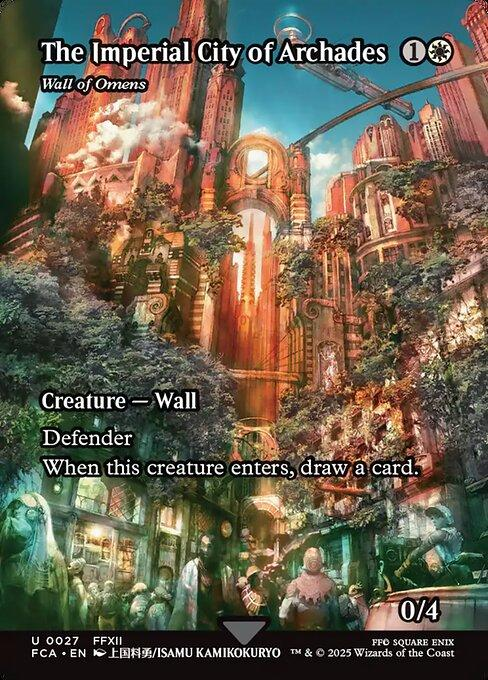

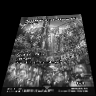

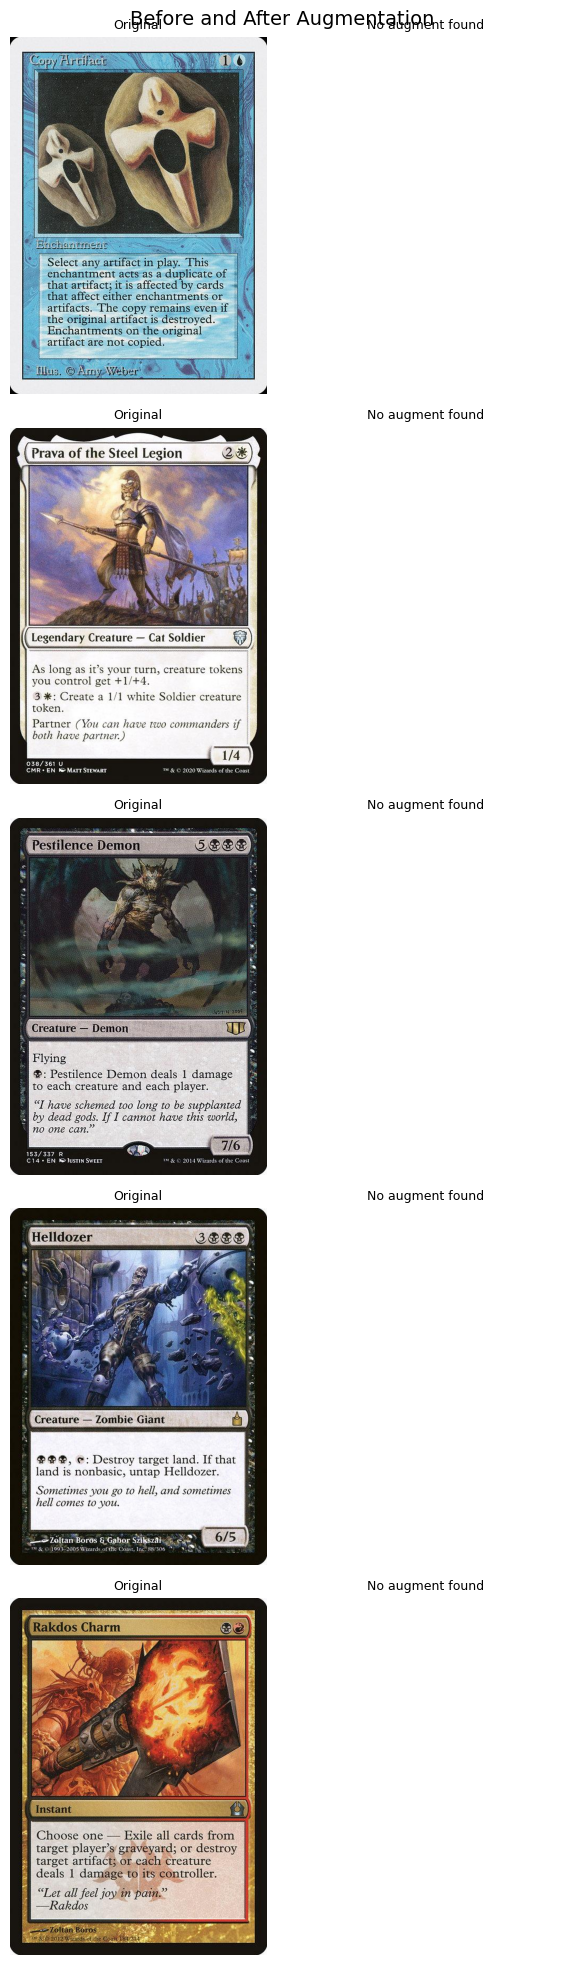

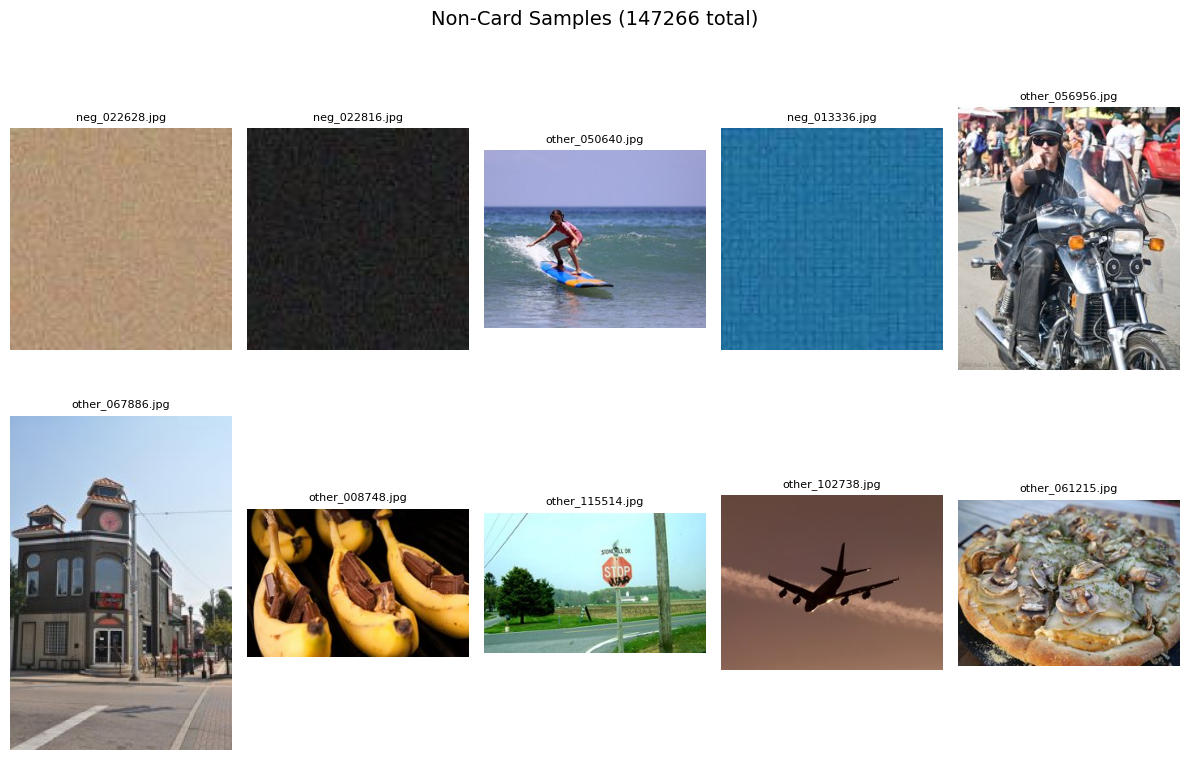

In [ ]:
# simple display of the before and after of the sample
display_simple()
show_augmented_samples()
show_non_card_samples()

# Data Preperation

---

In [ ]:
# # Load images from folders
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     DATA_DIR,
#     validation_split=0.2,
#     subset="training",
#     seed=123,
#     image_size=(IMAGE_SIZE, IMAGE_SIZE),
#     batch_size=BATCH_SIZE,
#     color_mode="grayscale"
# )

# val_ds = tf.keras.utils.image_dataset_from_directory(
#     DATA_DIR,
#     validation_split=0.2,
#     subset="validation",
#     seed=123,
#     image_size=(IMAGE_SIZE, IMAGE_SIZE),
#     batch_size=BATCH_SIZE,
#     color_mode="grayscale"
# )

# # Histogram equalization — normalize lighting to match camera inference
# def equalize_hist_batch(images, labels):
#     def _eq(img_batch):
#         out = np.empty_like(img_batch)
#         for i in range(img_batch.shape[0]):
#             frame = img_batch[i, :, :, 0].astype(np.uint8)
#             frame = cv2.equalizeHist(frame)
#             out[i, :, :, 0] = frame
#         return out.astype(np.float32)
#     equalized = tf.numpy_function(_eq, [images], tf.float32)
#     equalized.set_shape(images.shape)
#     return equalized, labels

# train_ds = train_ds.map(equalize_hist_batch, num_parallel_calls=tf.data.AUTOTUNE)
# val_ds = val_ds.map(equalize_hist_batch, num_parallel_calls=tf.data.AUTOTUNE)

# # Rescale pixels from [0, 255] to [0, 1]  — ONCE
# normalization_layer = tf.keras.layers.Rescaling(1./255)
# train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
# val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# # Online augmentation (training only)
# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip("horizontal"),
#     tf.keras.layers.RandomRotation(0.03),
#     tf.keras.layers.RandomContrast(0.15),
#     tf.keras.layers.RandomBrightness(0.1),
# ])

# train_ds = train_ds.cache()
# train_ds = train_ds.shuffle(10000)
# train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
#                         num_parallel_calls=tf.data.AUTOTUNE)
# train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Cards:     50000
Not-cards: 147266
Balanced to 50000 per class
Train: 85000   Val: 15000
Loaded 147266 background images for compositing

=== SANITY CHECK: new training positives ===
Should look like cards on desks/fabric/wood, NOT full-frame scans


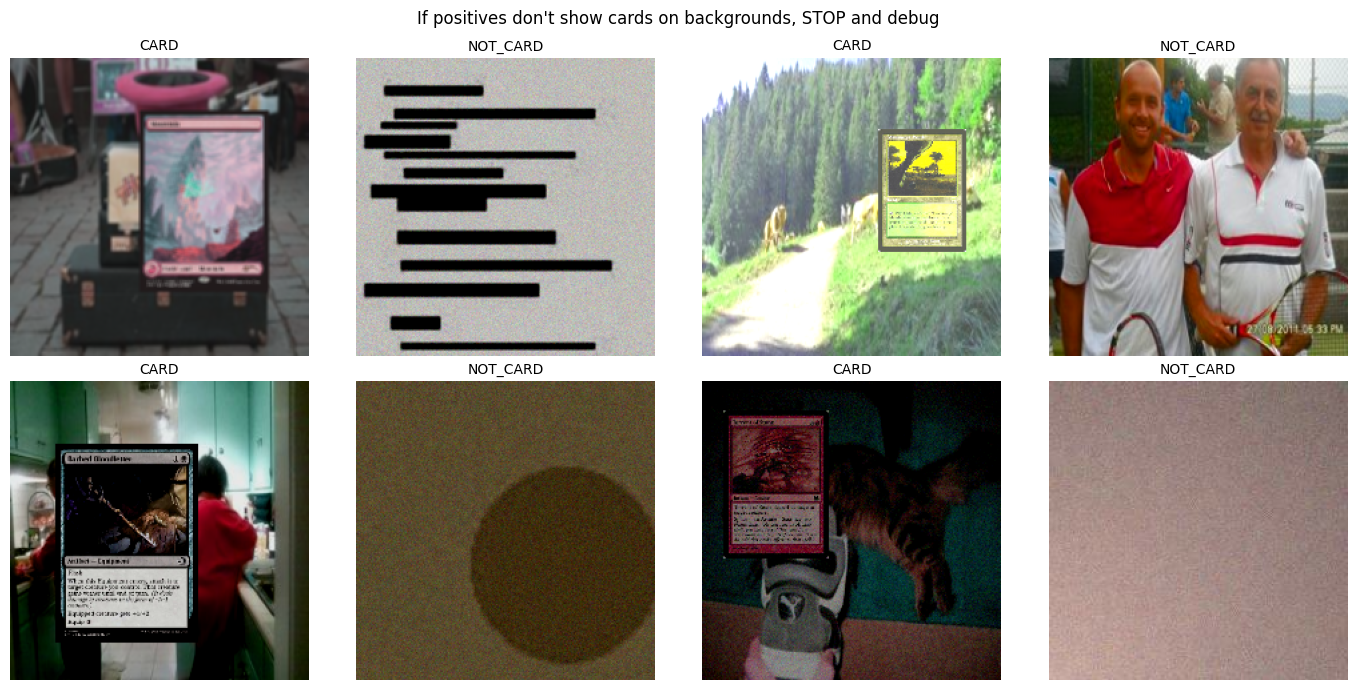

In [ ]:
card_files    = sorted(CARD_DIR.glob("*.jpg"))
notcard_files = sorted(NOT_CARD_DIR.glob("*.jpg"))

assert not any("_aug" in p.name for p in card_files), \
    "Delete _aug files first (see Cell 0)."

print(f"Cards:     {len(card_files)}")
print(f"Not-cards: {len(notcard_files)}")

# Balance: take min count from each class so 50/50
n = min(len(card_files), len(notcard_files))
rng = random.Random(SEED)
rng.shuffle(card_files)
rng.shuffle(notcard_files)
card_files    = card_files[:n]
notcard_files = notcard_files[:n]
print(f"Balanced to {n} per class")

# 85/15 split — BEFORE any augmentation
split = int(0.85 * n)
train_cards,  val_cards   = card_files[:split],    card_files[split:]
train_nocard, val_nocard  = notcard_files[:split], notcard_files[split:]

train_paths = [(str(p), 0) for p in train_cards]  + [(str(p), 1) for p in train_nocard]
val_paths   = [(str(p), 0) for p in val_cards]    + [(str(p), 1) for p in val_nocard]
rng.shuffle(train_paths); rng.shuffle(val_paths)

print(f"Train: {len(train_paths)}   Val: {len(val_paths)}")
# Label convention: 0 = card, 1 = not_card

# Key changes vs original:
#  - DROPPED partial_crop (was creating label noise)
#  - REDUCED perspective intensity 0.30 -> 0.10
#  - Moved to tf.data map so no aug files are ever written to disk

# ============================================================
# CAMERA-REALISTIC AUGMENTATION
# Positives: card composited onto real background + photometric aug
# Negatives: real backgrounds + matching photometric aug
# Both sides see the same lighting/noise so teacher learns
# content, not surface statistics.
# ============================================================

# Pre-load background paths once
_BG_PATHS_TF = tf.constant([str(p) for p in NOT_CARD_DIR.glob("*.jpg")])
print(f"Loaded {_BG_PATHS_TF.shape[0]} background images for compositing")

def _decode_rgb(path, target_size):
    raw = tf.io.read_file(path)
    img = tf.io.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, (target_size, target_size))
    return img


def composite_card_on_bg(card_path, size):
    """Paste card onto random background at 25-80% scale, random position."""
    card = _decode_rgb(card_path, size)

    bg_idx = tf.random.uniform([], 0, tf.shape(_BG_PATHS_TF)[0], dtype=tf.int32)
    bg = _decode_rgb(_BG_PATHS_TF[bg_idx], size)

    # Wider scale range — from "far away" (25%) to "close up" (80%)
    scale = tf.random.uniform([], 0.25, 0.80)
    card_h = tf.cast(tf.cast(size, tf.float32) * scale, tf.int32)
    card_w = tf.cast(tf.cast(card_h, tf.float32) * 0.72, tf.int32)  # MTG aspect
    card_resized = tf.image.resize(card, (card_h, card_w))

    # Random position — card must stay fully in frame
    max_y = size - card_h
    max_x = size - card_w
    y = tf.random.uniform([], 0, tf.maximum(max_y, 1), dtype=tf.int32)
    x = tf.random.uniform([], 0, tf.maximum(max_x, 1), dtype=tf.int32)

    pad_top    = y
    pad_bottom = size - y - card_h
    pad_left   = x
    pad_right  = size - x - card_w
    card_padded = tf.pad(card_resized,
                          [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]])
    mask = tf.pad(tf.ones((card_h, card_w, 1)),
                   [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]])
    return bg * (1.0 - mask) + card_padded * mask


def apply_camera_aug(img, channels):
    """Strong photometric aug to simulate webcam conditions."""
    # Lighting — wide range for room light variation
    img = tf.image.random_brightness(img, max_delta=0.35 * 255.0)
    img = tf.image.random_contrast(img, 0.6, 1.4)

    # Color casts — webcam white balance is never perfect
    if channels == 3:
        img = tf.image.random_saturation(img, 0.6, 1.4)
        img = tf.image.random_hue(img, 0.08)

    # Blur — cameras are rarely perfectly in focus
    if tf.random.uniform([]) < 0.4:
        img = tf.nn.avg_pool2d(img[tf.newaxis, ...], 3, 1, 'SAME')[0]

    # Sensor noise
    if tf.random.uniform([]) < 0.5:
        img = img + tf.random.normal(tf.shape(img), stddev=0.04 * 255.0)

    # JPEG compression artifacts (matches browser capture)
    if tf.random.uniform([]) < 0.5 and channels == 3:
        img_u8 = tf.cast(tf.clip_by_value(img, 0.0, 255.0), tf.uint8)
        img_u8 = tf.image.random_jpeg_quality(img_u8, 50, 90)
        img = tf.cast(img_u8, tf.float32)

    img = tf.clip_by_value(img, 0.0, 255.0)
    return img


def load_card_composited(path, label, size, channels, augment):
    """Card pasted onto real background."""
    img = composite_card_on_bg(path, size)
    if augment:
        img = apply_camera_aug(img, channels=3)  # aug in RGB then convert
    if channels == 1:
        img = tf.image.rgb_to_grayscale(img)
    return img / 255.0, label


def load_negative(path, label, size, channels, augment):
    """Real background, same photometric aug."""
    raw = tf.io.read_file(path)
    img = tf.io.decode_jpeg(raw, channels=3)
    if augment:
        big = tf.cast(size * tf.random.uniform([], 1.0, 1.15), tf.int32)
        img = tf.image.resize(img, (big, big))
        img = tf.image.random_crop(img, (size, size, 3))
        img = apply_camera_aug(img, channels=3)
    else:
        img = tf.image.resize(img, (size, size))
    if channels == 1:
        img = tf.image.rgb_to_grayscale(img)
    return img / 255.0, label


def load_any(path, label, size, channels, augment):
    """Route positives through compositing, negatives through straight load."""
    return tf.cond(
        tf.equal(label, 0),
        lambda: load_card_composited(path, label, size, channels, augment),
        lambda: load_negative(path, label, size, channels, augment),
    )


def make_ds(pairs, size, channels, augment, shuffle):
    paths  = [p for p, _ in pairs]
    labels = [l for _, l in pairs]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, l: load_any(p, l, size, channels, augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Teacher: RGB @ TEACHER_SIZE
teacher_train_ds = make_ds(train_paths, TEACHER_SIZE, 3, augment=True,  shuffle=True)
teacher_val_ds   = make_ds(val_paths,   TEACHER_SIZE, 3, augment=False, shuffle=False).cache()

# Student: grayscale @ STUDENT_SIZE
student_train_ds = make_ds(train_paths, STUDENT_SIZE, 1, augment=True,  shuffle=True)
student_val_ds   = make_ds(val_paths,   STUDENT_SIZE, 1, augment=False, shuffle=False)

# Sanity check — positives should look like camera views, not scans
print("\n=== SANITY CHECK: new training positives ===")
print("Should look like cards on desks/fabric/wood, NOT full-frame scans")
for imgs, lbls in teacher_train_ds.take(1):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i].numpy())
        ax.set_title(f"{'CARD' if lbls[i].numpy() == 0 else 'NOT_CARD'}", fontsize=10)
        ax.axis('off')
    plt.suptitle("If positives don't show cards on backgrounds, STOP and debug", fontsize=12)
    plt.tight_layout(); plt.show()

In [ ]:
print(f"Cards:     {len(list(CARD_DIR.glob('*.jpg')))}")
print(f"Not-cards: {len(list(NOT_CARD_DIR.glob('*.jpg')))}")

Cards:     50000
Not-cards: 147266


# Define TinyConv Model (Teacher)

---

In [ ]:
def build_teacher(input_size=TEACHER_SIZE):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(input_size, input_size, 3),
        include_top=False,
        weights='imagenet',
        alpha=1.0,
    )
    base.trainable = False  # stage 1: frozen

    inputs = layers.Input(shape=(input_size, input_size, 3))
    # MobileNetV2 expects [-1, 1]; our ds yields [0, 1]
    x = layers.Rescaling(2.0, offset=-1.0)(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    logits = layers.Dense(2, name='logits')(x)
    probs  = layers.Softmax(name='probs')(logits)
    probs_model  = Model(inputs, probs,  name='teacher')
    logits_model = Model(inputs, logits, name='teacher_logits')
    return probs_model, logits_model, base

teacher, teacher_logits_model, teacher_backbone = build_teacher()
teacher.summary()

# --- Stage 1: frozen backbone, train the head only ---
teacher.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
rlr   = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

print("=== Teacher stage 1: head only ===")
teacher.fit(teacher_train_ds, validation_data=teacher_val_ds,
            epochs=TEACHER_EPOCHS_HEAD, callbacks=[early, rlr])

# --- Stage 2: unfreeze top 30 layers for fine-tuning ---
teacher_backbone.trainable = True
for layer in teacher_backbone.layers[:-30]:
    layer.trainable = False

teacher.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),   # lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
print("=== Teacher stage 2: fine-tune top 30 layers ===")
teacher.fit(teacher_train_ds, validation_data=teacher_val_ds,
            epochs=TEACHER_EPOCHS_FT, callbacks=[early, rlr])

teacher_loss, teacher_acc = teacher.evaluate(teacher_val_ds, verbose=0)
print(f"\n*** Teacher val accuracy: {teacher_acc*100:.2f}% ***")
teacher.save(MODEL_DIR / "teacher.keras")

# model = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),

#     # First Convolution: Find edges/corners
#     tf.keras.layers.Conv2D(8, (3, 3), strides=(2, 2), padding='same', activation='relu'),

#     # Using padding='valid' ensures MaxPool V1 compatibility
#     # Since the input to this layer is 48x48 (due to the Conv2D stride),
#     # it will downsample to 24x24.
#     tf.keras.layers.MaxPooling2D((2, 2), padding='valid'),

#     # Second Convolution: Find card shapes
#     tf.keras.layers.Conv2D(16, (3, 3), strides=(2, 2), padding='same', activation='relu'),
#     tf.keras.layers.BatchNormalization(),

#     # Flatten and Classify (0 = Not Card, 1 = Card)
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(1, activation='softmax')
# ])

# model.compile(optimizer='adam',
#               loss='binary_crossentropy',
#               metrics=['accuracy'])

def build_student(input_size=STUDENT_SIZE):
    inputs = layers.Input(shape=(input_size, input_size, 1))

    # Stem
    x = layers.Conv2D(16, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)     # 48x48x16

    # Block 1 — depthwise separable
    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(32, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)                                # 24x24x32

    # Block 2
    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(48, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)                                # 12x12x48

    # Block 3
    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(64, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)                                # 6x6x64

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    logits = layers.Dense(2, name='logits')(x)
    probs  = layers.Softmax(name='probs')(logits)
    return Model(inputs, probs, name='student'), Model(inputs, logits, name='student_logits')

student, student_logits_model = build_student()
student.summary()
print(f"Student params: {student.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "teacher"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 2)              │         2,562 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Softmax)                 │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 48, 48, 16)     │           144 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 24, 24, 32)     │           288 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 48)     │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 24, 24, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_2              │ (None, 12, 12, 48)     │           432 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 7,282 (28.45 KB)

 Trainable params: 6,770 (26.45 KB)

 Non-trainable params: 512 (2.00 KB)

Student params: 7,282


# Define TinyConv Mdoel (Student)

In [ ]:
# ============================================================
# Paired KD dataset — both views derived from one composited scene
# ============================================================
def make_kd_ds(pairs, augment, shuffle):
    paths  = [p for p, _ in pairs]
    labels = [l for _, l in pairs]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)

    def _pair(p, l):
        # Teacher-resolution RGB through the SAME pipeline that trained the teacher
        img_t, lbl = load_any(p, l, TEACHER_SIZE, 3, augment)   # ([0,1] RGB, label)
        # Student view: grayscale @ STUDENT_SIZE, derived from the SAME pixels
        img_s = tf.image.rgb_to_grayscale(img_t)
        img_s = tf.image.resize(img_s, (STUDENT_SIZE, STUDENT_SIZE))
        img_s.set_shape([STUDENT_SIZE, STUDENT_SIZE, 1])
        img_t.set_shape([TEACHER_SIZE, TEACHER_SIZE, 3])
        return (img_s, img_t), lbl

    ds = ds.map(_pair, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Replace the old kd_train_ds / kd_val_ds
kd_train_ds = make_kd_ds(train_paths, augment=True,  shuffle=True)
kd_val_ds   = make_kd_ds(val_paths,   augment=False, shuffle=False)

# Sanity: shapes should be ((B,96,96,1), (B,224,224,3)), labels (B,)
for (s, t), y in kd_train_ds.take(1):
    print(f"student batch: {s.shape}  teacher batch: {t.shape}  labels: {y.shape}")
    print(f"student range: [{tf.reduce_min(s):.3f}, {tf.reduce_max(s):.3f}]")
    print(f"teacher range: [{tf.reduce_min(t):.3f}, {tf.reduce_max(t):.3f}]")

# ============================================================
# Distiller — custom train_step / test_step
# ============================================================
class Distiller(tf.keras.Model):
    def __init__(self, student_logits, teacher_logits, temperature=4.0, alpha=0.7):
        super().__init__()
        self.student_logits = student_logits
        self.teacher_logits = teacher_logits
        self.temperature = float(temperature)
        self.alpha = float(alpha)

        self.loss_tr      = tf.keras.metrics.Mean(name='loss')
        self.kd_loss_tr   = tf.keras.metrics.Mean(name='kd')
        self.hard_loss_tr = tf.keras.metrics.Mean(name='hard')
        self.acc_tr       = tf.keras.metrics.SparseCategoricalAccuracy(name='acc')

    @property
    def metrics(self):
        return [self.loss_tr, self.kd_loss_tr, self.hard_loss_tr, self.acc_tr]

    def compile(self, optimizer):
        super().compile(optimizer=optimizer)
        self.hard_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
        self.kd_loss   = tf.keras.losses.KLDivergence()

    def train_step(self, data):
        (s_in, t_in), y = data

        # Teacher: no gradient, eval mode (frozen BN)
        t_logits = self.teacher_logits(t_in, training=False)

        with tf.GradientTape() as tape:
            s_logits = self.student_logits(s_in, training=True)

            T = self.temperature
            kd = self.kd_loss(
                tf.nn.softmax(t_logits / T, axis=-1),
                tf.nn.softmax(s_logits / T, axis=-1),
            ) * (T * T)

            hard = self.hard_loss(y, s_logits)
            loss = self.alpha * kd + (1.0 - self.alpha) * hard

        grads = tape.gradient(loss, self.student_logits.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student_logits.trainable_variables))

        self.loss_tr.update_state(loss)
        self.kd_loss_tr.update_state(kd)
        self.hard_loss_tr.update_state(hard)
        self.acc_tr.update_state(y, s_logits)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (s_in, t_in), y = data
        s_logits = self.student_logits(s_in, training=False)
        hard = self.hard_loss(y, s_logits)
        self.loss_tr.update_state(hard)
        self.hard_loss_tr.update_state(hard)
        self.acc_tr.update_state(y, s_logits)
        return {'loss': self.loss_tr.result(),
                'hard': self.hard_loss_tr.result(),
                'acc':  self.acc_tr.result()}

import math

# ============================================================
# Stage A — short hard-label warmup on student_train_ds
# ============================================================
print("=== Stage A: hard-label warmup ===")
student.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
student.fit(
    student_train_ds,
    validation_data=student_val_ds,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=1, min_lr=1e-5),
    ],
    verbose=1,
)
warm_loss, warm_acc = student.evaluate(student_val_ds, verbose=0)
print(f"After warmup: val acc = {warm_acc*100:.2f}%")

# ============================================================
# Stage B — full distillation
# ============================================================
print("\n=== Stage B: knowledge distillation ===")

# Cosine LR decay across STUDENT_EPOCHS
steps_per_epoch = tf.data.experimental.cardinality(kd_train_ds).numpy()
total_steps     = max(steps_per_epoch * STUDENT_EPOCHS, 1)
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_steps,
    alpha=0.02,           # final LR = 2e-5
)

distiller = Distiller(
    student_logits=student_logits_model,
    teacher_logits=teacher_logits_model,
    temperature=KD_TEMPERATURE,
    alpha=KD_ALPHA,
)
distiller.compile(optimizer=tf.keras.optimizers.Adam(lr_schedule))

# Save the *probs* student (what you actually use for inference / TFLite)
ckpt_path = str(MODEL_DIR / "student_best.keras")
class SaveBestStudent(tf.keras.callbacks.Callback):
    def __init__(self, path, monitor='val_acc'):
        super().__init__()
        self.path = path
        self.monitor = monitor
        self.best = -float('inf')
    def on_epoch_end(self, epoch, logs=None):
        v = (logs or {}).get(self.monitor)
        if v is None: return
        if v > self.best:
            self.best = v
            student.save(self.path)   # save the probs model, not the distiller wrapper
            print(f"  ✓ saved {self.path} (val_acc={v*100:.2f}%)")

distiller.fit(
    kd_train_ds,
    validation_data=kd_val_ds,
    epochs=STUDENT_EPOCHS,
    callbacks=[
        SaveBestStudent(ckpt_path, monitor='val_acc'),
        tf.keras.callbacks.EarlyStopping(monitor='val_acc', mode='max',
                                         patience=5, restore_best_weights=False),
    ],
    verbose=1,
)

# Reload the BEST checkpoint, not whatever the last epoch was
student = tf.keras.models.load_model(MODEL_DIR / "student_best.keras")
loss, acc = student.evaluate(student_val_ds, verbose=0)
print(f"Float student val accuracy: {acc*100:.2f}%")

# Compare against the teacher on the same images so you know your headroom
teacher_loss, teacher_acc = teacher.evaluate(teacher_val_ds, verbose=0)
print(f"Teacher val accuracy:      {teacher_acc*100:.2f}%")
print(f"Student/teacher gap:       {(teacher_acc - acc)*100:.2f} pp")

# Per-class spot check
import random as _rnd
print("\nSpot-check on random val cards:")
for p in _rnd.sample(list(CARD_DIR.glob("*.jpg")), 5):
    img = Image.open(p).convert("L").resize((STUDENT_SIZE, STUDENT_SIZE), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = arr[None, ..., None]
    pred = student.predict(arr, verbose=0)[0]
    print(f"  {p.name}: card={pred[0]:.3f} → {'CARD' if pred[0]>pred[1] else 'NOT CARD'}")

student batch: (64, 96, 96, 1)  teacher batch: (64, 224, 224, 3)  labels: (64,)
student range: [0.000, 1.000]
teacher range: [0.000, 1.000]
=== Stage A: hard-label warmup ===
Epoch 1/5
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 251s 183ms/step - accuracy: 0.8247 - loss: 0.3924 - val_accuracy: 0.9346 - val_loss: 0.1849 - learning_rate: 0.0010
Epoch 2/5
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 260s 195ms/step - accuracy: 0.9167 - loss: 0.2215 - val_accuracy: 0.9467 - val_loss: 0.1630 - learning_rate: 0.0010
Epoch 3/5
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 231s 174ms/step - accuracy: 0.9329 - loss: 0.1842 - val_accuracy: 0.9246 - val_loss: 0.2391 - learning_rate: 0.0010
Epoch 4/5
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 241s 181ms/step - accuracy: 0.9443 - loss: 0.1564 - val_accuracy: 0.9659 - val_loss: 0.1088 - learning_rate: 5.0000e-04
Epoch 5/5
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 238s 179ms/step - accuracy: 0.9468 - loss: 0.1490 - val_accuracy: 0.9655 - val_loss: 0.1050 - learning_rate: 5.0000e-04
After warmup: val acc = 96.43%



# Raw Camera Detection

---





In [ ]:
def load_paired(path, label):
    """Returns ((student_gray_96, teacher_rgb_160), label) with shared augmentation."""
    raw = tf.io.read_file(path)
    img_rgb = tf.io.decode_jpeg(raw, channels=3)

    # Augment in RGB first, then derive student's grayscale view
    big = tf.cast(TEACHER_SIZE * tf.random.uniform([], 1.0, 1.12), tf.int32)
    img = tf.image.resize(img_rgb, (big, big))
    img = tf.image.random_crop(img, (TEACHER_SIZE, TEACHER_SIZE, 3))
    img = tf.image.random_brightness(img, 0.15 * 255.0)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 255.0)

    img_gray = tf.image.rgb_to_grayscale(img)
    img_gray = tf.image.resize(img_gray, (STUDENT_SIZE, STUDENT_SIZE))
    return (img_gray / 255.0, img / 255.0), label


def load_paired_val(path, label):
    raw = tf.io.read_file(path)
    img_rgb = tf.io.decode_jpeg(raw, channels=3)
    img_rgb = tf.image.resize(img_rgb, (TEACHER_SIZE, TEACHER_SIZE))
    img_gray = tf.image.rgb_to_grayscale(img_rgb)
    img_gray = tf.image.resize(img_gray, (STUDENT_SIZE, STUDENT_SIZE))
    return (img_gray / 255.0, img_rgb / 255.0), label


def make_paired_ds(pairs, shuffle, augment):
    paths  = [p for p, _ in pairs]
    labels = [l for _, l in pairs]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
    loader = load_paired if augment else load_paired_val
    ds = ds.map(loader, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


kd_train_ds = make_paired_ds(train_paths, shuffle=True,  augment=True)
kd_val_ds   = make_paired_ds(val_paths,   shuffle=False, augment=False)

In [ ]:
# === DIAGNOSTIC: Does the model work on its own data? ===
import random as _rnd

print("Testing STUDENT on card images:")
card_test = _rnd.sample(list(CARD_DIR.glob("*.jpg")), 5)
for p in card_test:
    img = Image.open(p).convert("L").resize((STUDENT_SIZE, STUDENT_SIZE), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(np.expand_dims(arr, axis=-1), axis=0)
    pred = student.predict(arr, verbose=0)[0]
    print(f"  {p.name}: card={pred[0]:.3f}, not_card={pred[1]:.3f} → {'CARD' if pred[0]>pred[1] else 'NOT CARD'}")

print("\nTesting STUDENT on not-card images:")
nc_test = _rnd.sample(list(NOT_CARD_DIR.glob("*.jpg")), 5)
for p in nc_test:
    img = Image.open(p).convert("L").resize((STUDENT_SIZE, STUDENT_SIZE), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(np.expand_dims(arr, axis=-1), axis=0)
    pred = student.predict(arr, verbose=0)[0]
    print(f"  {p.name}: card={pred[0]:.3f}, not_card={pred[1]:.3f} → {'CARD' if pred[0]>pred[1] else 'NOT CARD'}")

In [ ]:
# --- Run it! ---
print("=" * 60)
print("  LIVE CAMERA INFERENCE — TEACHER MODEL")
print("=" * 60)
print(f"  Teacher params: {teacher.count_params():,}")
print(f"  Input: {TEACHER_SIZE}x{TEACHER_SIZE} RGB")
print("=" * 60)

run_teacher_camera_inference(teacher, num_frames=200, fps_target=5)

In [ ]:
# --- Run it! ---
print("=" * 60)
print("  LIVE CAMERA INFERENCE — UNCOMPRESSED KERAS MODEL")
print("=" * 60)
print(f"  Model: {student.count_params()} parameters (full float32)")
print(f"  Input: {IMAGE_SIZE}x{IMAGE_SIZE} grayscale")
print(f"  Output: sigmoid — P(card)")
print("=" * 60)

run_live_camera_inference(student, num_frames=200, fps_target=5)

# Model Accuracy (before quantization)

---

In [ ]:
# Evaluate the original float model on the validation dataset
student = tf.keras.models.load_model(MODEL_DIR / "student_best.keras")
loss, acc = student.evaluate(student_val_ds, verbose=0)
print(f"Float student val accuracy: {acc*100:.2f}%")

# Quantize Model

---

In [ ]:
# Representative dataset needed for full integer quantization
def representative_data_gen():
  # Take 100 batches from the dataset
  for input_value, _ in student_train_ds.take(100):
    # Loop through each individual image in the batch
    for i in range(input_value.shape[0]):
      # Expand dims to make it [1, 96, 96, 1]
      single_img = tf.expand_dims(input_value[i], axis=0)
      yield [single_img]

# Export as a standard TFLite model
converter = tf.lite.TFLiteConverter.from_keras_model(student)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model_int8 = converter.convert()

# Save the model
with open('mtg_detector.tflite', 'wb') as f:
    f.write(tflite_model_int8)
(MODEL_DIR / "mtg_detector.tflite").write_bytes(tflite_model_int8)
print(f"Saved mtg_detector.tflite  ({len(tflite_model_int8)/1024:.1f} KB)")

# Model Accuracy (after quantization)

---

In [ ]:
def evaluate_tflite_model(tflite_model_path, dataset):
    # Load the TFLite model and allocate tensors
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    correct_predictions = 0
    total_predictions = 0

    # Iterate through the validation dataset
    for images, labels in dataset:
        for i in range(len(images)):
            # TFLite INT8 models expect data in a specific range and type
            input_data = images[i:i+1].numpy()

            # If the model is quantized to INT8, rescale/cast the input
            if input_details['dtype'] == np.int8:
                scale, zero_point = input_details['quantization']
                input_data = input_data / scale + zero_point
                input_data = input_data.astype(np.int8)

            interpreter.set_tensor(input_details['index'], input_data)
            interpreter.invoke()

            # Get the output and compare to label
            output = interpreter.get_tensor(output_details['index'])
            prediction = np.argmax(output[0])

            if prediction == labels[i].numpy():
                correct_predictions += 1
            total_predictions += 1

    return correct_predictions / total_predictions

# Run the evaluation on the held-out validation set
quantized_accuracy = evaluate_tflite_model('mtg_detector.tflite', student_val_ds)
print(f"Quantized TFLite Model Accuracy: {quantized_accuracy * 100:.2f}%")
print(f"Float → INT8 drop: {(acc - quantized_accuracy) * 100:.2f} pp")

# Convert to C Array

---

In [ ]:
!apt-get update && apt-get install xxd
!xxd -i mtg_detector.tflite > mtg_model_data.cc

# Rename generated symbols to match what the Arduino code expects
!sed -i 's/mtg_detector_tflite_len/g_person_detect_model_data_len/g' mtg_model_data.cc
!sed -i 's/mtg_detector_tflite/g_person_detect_model_data/g'         mtg_model_data.cc
!ls -lh mtg_detector.tflite mtg_model_data.cc

# Compare Metrics

---

In [ ]:
def get_file_size(file_path):
    size = os.path.getsize(file_path)
    return size / 1024  # Size in KB

# Assuming you saved the baseline Keras model
student.save("baseline_model.h5")

print("--- Final Comparison ---")
print(f"Baseline Accuracy:  {acc * 100:.2f}%")
print(f"Quantized Accuracy: {quantized_accuracy * 100:.2f}%")
print(f"Accuracy Drop:      {(acc - quantized_accuracy) * 100:.2f}%")
print("------------------------")
print(f"Baseline Size:      {get_file_size('baseline_model.h5'):.2f} KB")
print(f"Quantized Size:     {get_file_size('mtg_detector.tflite'):.2f} KB")